# 模块 08：RNN / LSTM

## 1. 理论背景
RNN 用隐藏状态携带历史信息，适合序列任务。LSTM 通过输入门、遗忘门、输出门和记忆单元缓解长序列中的梯度消失。

## 1.1 实际作用（用途）
- 用于时间序列预测、语音识别、文本分类、传感器数据分析和用户行为序列建模。
- RNN 适合短期上下文，LSTM/GRU 更适合长序列依赖。
- 在资源受限、低延迟或流式数据场景中仍有实用价值。

## 2. 数学推导
基本 RNN：$h_t=\tanh(W_xx_t+W_hh_{t-1}+b)$。

LSTM：
$$i_t=\sigma(W_i[h_{t-1},x_t]+b_i),\ f_t=\sigma(W_f[h_{t-1},x_t]+b_f),\ o_t=\sigma(W_o[h_{t-1},x_t]+b_o)$$
$$\tilde c_t=\tanh(W_c[h_{t-1},x_t]+b_c),\ c_t=f_tc_{t-1}+i_t\tilde c_t,\ h_t=o_t\tanh(c_t)$$

## 3. 代码思路

本章代码从单个 LSTM cell 展开到完整序列：

1. `lstm_cell` 接收当前输入 `x_t`、上一时刻隐藏状态 `h_prev` 和记忆状态 `c_prev`。
2. 先把 `h_prev` 和 `x_t` 拼接，一次矩阵乘法同时得到输入门、遗忘门、输出门和候选记忆。
3. 三个门用 Sigmoid 控制信息通过比例，候选记忆用 Tanh 产生可写入的新内容。
4. 用 `c = f * c_prev + i * g` 更新长期记忆，再用 `h = o * tanh(c)` 生成当前隐藏状态。
5. 外层循环按时间步处理整段序列，并保存每一步的隐藏状态用于观察序列信息如何演化。

## 4. NumPy 实现

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

def sigmoid(x): return 1 / (1 + np.exp(-x))

def lstm_cell(x_t, h_prev, c_prev, W, b):
    # 把上一个隐藏状态和当前输入拼接，统一计算四组门。
    concat = np.concatenate([h_prev, x_t])
    gates = concat @ W + b
    i, f, o, g = np.split(gates, 4)
    # 输入门 i、遗忘门 f、输出门 o 使用 sigmoid，范围在 0 到 1。
    i, f, o = sigmoid(i), sigmoid(f), sigmoid(o)
    # 候选记忆 g 使用 tanh，提供可写入细胞状态的新信息。
    g = np.tanh(g)
    c = f * c_prev + i * g
    h = o * np.tanh(c)
    return h, c, {'i': i, 'f': f, 'o': o, 'g': g}

rng = np.random.default_rng(3)
input_size, hidden_size = 2, 3
# W 一次性存放四个门的参数，所以输出维度是 4 * hidden_size。
W = rng.normal(scale=0.3, size=(input_size + hidden_size, 4 * hidden_size))
b = np.zeros(4 * hidden_size)
sequence = rng.normal(size=(6, input_size))
h = np.zeros(hidden_size); c = np.zeros(hidden_size)
states = []
# 按时间步顺序递推，h/c 会把历史信息带到下一个时间步。
for x_t in sequence:
    h, c, gates = lstm_cell(x_t, h, c, W, b)
    states.append(h.copy())
states = np.array(states)
print("序列展开结果：每一行是一个时间步的 LSTM 隐藏状态 h_t，用来表示截至当前时间步的序列信息。\n", states)


序列展开结果：每一行是一个时间步的 LSTM 隐藏状态 h_t，用来表示截至当前时间步的序列信息。
 [[-0.0089 -0.1388 -0.1037]
 [-0.2009 -0.1307 -0.079 ]
 [ 0.0122 -0.244  -0.1806]
 [-0.124   0.0372 -0.0453]
 [ 0.0135 -0.1401 -0.17  ]
 [ 0.0805 -0.0536 -0.0885]]


## 5. 结果验证

In [2]:
assert states.shape == (6, hidden_size)
try:
    import torch
    # 只验证第一个时间步，便于和手写 lstm_cell 逐项对照。
    xt = torch.tensor(sequence[0], dtype=torch.float64)
    hp = torch.zeros(hidden_size, dtype=torch.float64)
    cp = torch.zeros(hidden_size, dtype=torch.float64)
    Wt = torch.tensor(W, dtype=torch.float64)
    bt = torch.tensor(b, dtype=torch.float64)
    gates_t = torch.cat([hp, xt]) @ Wt + bt
    it, ft, ot, gt = torch.chunk(gates_t, 4)
    ct = torch.sigmoid(ft) * cp + torch.sigmoid(it) * torch.tanh(gt)
    ht = torch.sigmoid(ot) * torch.tanh(ct)
    hn, cn, _ = lstm_cell(sequence[0], np.zeros(hidden_size), np.zeros(hidden_size), W, b)
    assert np.allclose(ht.numpy(), hn, atol=1e-5)
    print('验证通过：手写 LSTM cell 的门控计算与 PyTorch 张量运算结果一致。')
except ImportError:
    print('提示：当前环境未安装 PyTorch；LSTM 隐藏状态形状与递推检查已通过。')


验证通过：手写 LSTM cell 的门控计算与 PyTorch 张量运算结果一致。


## 6. 可视化

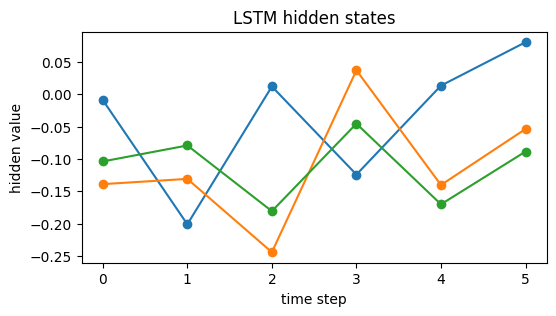

In [3]:
plt.figure(figsize=(6, 3))
# 每条曲线对应隐藏状态 h_t 的一个维度，展示它随时间如何变化。
plt.plot(states, marker='o')
plt.xlabel('time step'); plt.ylabel('hidden value'); plt.title('LSTM hidden states'); plt.show()
